# 1. DÉCOMPRESSION DU FICHIER ZIP EN LOCAL SUR COLAB

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. IMPORTS ET CONFIGURATIONS

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Rescaling
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.utils import image_dataset_from_directory

img_height = 96
img_width = 96
batch_size = 32

# Les NOUVEAUX chemins qui pointent vers ton Google Drive
# J'ai supposé que ton dossier s'appelle "dataset" à l'intérieur de "Colab Notebooks"
train_dir = '/content/drive/MyDrive/Colab Notebooks/dataset/train'
val_dir = '/content/drive/MyDrive/Colab Notebooks/dataset/validation'
test_dir = '/content/drive/MyDrive/Colab Notebooks/dataset/test'

#3. CHARGEMENT DU DATASET

In [19]:
print("Chargement des données d'entraînement :")
train_dataset = image_dataset_from_directory(train_dir, image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical')

print("Chargement des données de validation :")
val_dataset = image_dataset_from_directory(val_dir, image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical')

print("Chargement des données de test :")
test_dataset = image_dataset_from_directory(test_dir, image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical')

class_names = train_dataset.class_names
print("Classes détectées par l'IA :", class_names)

Chargement des données d'entraînement :
Found 157 files belonging to 2 classes.
Chargement des données de validation :
Found 20 files belonging to 2 classes.
Chargement des données de test :
Found 20 files belonging to 2 classes.
Classes détectées par l'IA : ['apple', 'pear']


#3. CNN

In [20]:
modele = Sequential()

# 1. Data Augmentation (Génère de fausses nouvelles images en les tournant/zoomant)
modele.add(RandomFlip("horizontal", input_shape=(img_height, img_width, 3)))
modele.add(RandomRotation(0.1))
modele.add(RandomZoom(0.1))

# 2. Normalisation des pixels (de 0 à 1 au lieu de 0 à 255)
modele.add(Rescaling(1./255))

# 3. Les couches de Convolution (Extraction des formes)
modele.add(Conv2D(32, kernel_size=3, padding='same', activation='relu'))
modele.add(MaxPooling2D(pool_size=(2,2)))

modele.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
modele.add(MaxPooling2D(pool_size=(2,2)))

# 4. Aplatissement et Décision finale
modele.add(Flatten())
modele.add(Dense(2, activation='softmax')) # 2 sorties : Apple ou Pear

modele.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(modele.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        73,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,122 (363.76 KB)

 Trainable params: 93,122 (363.76 KB)

 Non-trainable params: 0 (0.00 B)

None


#4. ENTRAINEMENT

In [21]:
epochs = 15
historique = modele.fit(train_dataset, validation_data=val_dataset, epochs=epochs)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.5287 - loss: 1.3093 - val_accuracy: 0.5000 - val_loss: 0.9313
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 955ms/step - accuracy: 0.5669 - loss: 0.7850 - val_accuracy: 0.7000 - val_loss: 0.5882
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 582ms/step - accuracy: 0.7834 - loss: 0.5699 - val_accuracy: 0.9500 - val_loss: 0.4133
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 700ms/step - accuracy: 0.8599 - loss: 0.4544 - val_accuracy: 0.9500 - val_loss: 0.2533
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.8535 - loss: 0.3740 - val_accuracy: 0.9500 - val_loss: 0.1579
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 616ms/step - accuracy: 0.8790 - loss: 0.3418 - val_accuracy: 0.9500 - val_loss: 0.1459
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 614ms/step - accuracy: 0.8790 - loss: 0.3354 - val_accuracy: 1.0000 - val_loss: 0.1079
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 960ms/step - accuracy: 0.8917 - loss: 0.3259 - val_accuracy: 0.9500 - val_loss: 0

#5. FS5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


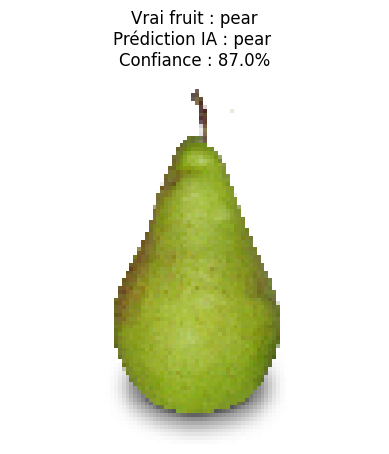

In [22]:
# On prend un petit groupe d'images dans le dossier de test
for images, labels in test_dataset.take(1):
    image_test = images[0]
    label_vrai = class_names[np.argmax(labels[0])]

    # L'IA fait sa prédiction
    prediction = modele.predict(tf.expand_dims(image_test, 0))
    pourcentage_1 = prediction[0][0] * 100
    pourcentage_2 = prediction[0][1] * 100

    label_predit = class_names[np.argmax(prediction[0])]
    confiance = max(pourcentage_1, pourcentage_2)

    # On affiche le résultat de façon visuelle
    plt.imshow(image_test.numpy().astype("uint8"))
    plt.title(f"Vrai fruit : {label_vrai}\nPrédiction IA : {label_predit} \nConfiance : {confiance:.1f}%")
    plt.axis("off")
    plt.show()

#6. FS6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Voici ce que le réseau de neurones 'voit' à l'intérieur de ses couches :


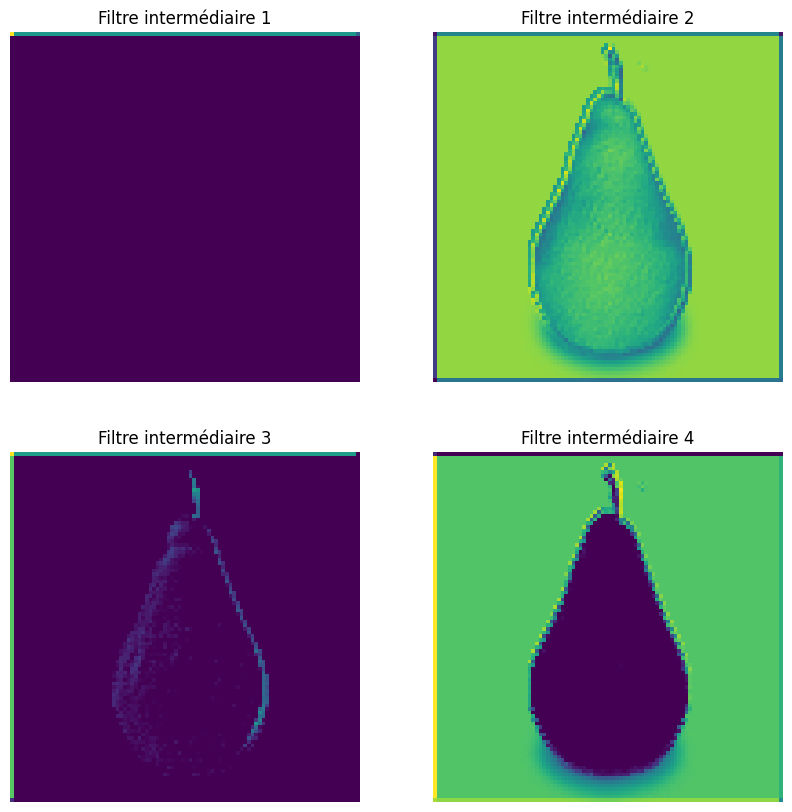

In [23]:
# On crée un modèle temporaire qui s'arrête à la première couche Conv2D (index 4)
couche_convolution = modele.layers[4]
modele_intermediaire = keras.Model(inputs=modele.inputs, outputs=couche_convolution.output)

# On fait passer notre image de test dedans
feature_maps = modele_intermediaire.predict(tf.expand_dims(image_test, 0))

# On affiche 4 exemples de la façon dont l'IA "voit" les contours du fruit
print("Voici ce que le réseau de neurones 'voit' à l'intérieur de ses couches :")
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    # On affiche le filtre numéro i
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Filtre intermédiaire {i+1}")
    plt.axis("off")
plt.show()

#7. Sauvegarde des poids

In [26]:
# Sauvegarde du modèle complet (architecture + poids)
modele.save('mon_modele_pomme_poire.keras')
print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !
